# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

## Deskripsi Dataset

Dataset Titanic merupakan salah satu dataset paling populer dalam dunia machine learning. Dataset ini berisi informasi tentang penumpang kapal Titanic yang tenggelam pada tahun 1912.

### Fitur-fitur Dataset:
| Kolom | Tipe | Deskripsi |
|---|---|---|
| survived | int | Target: 0 = Tidak Selamat, 1 = Selamat |
| pclass | int | Kelas tiket (1, 2, 3) |
| sex | str | Jenis kelamin penumpang |
| age | float | Usia penumpang |
| sibsp | int | Jumlah saudara/pasangan di kapal |
| parch | int | Jumlah orang tua/anak di kapal |
| fare | float | Harga tiket |
| embarked | str | Pelabuhan keberangkatan (C, Q, S) |
| class | str | Kelas penumpang (First, Second, Third) |
| who | str | Kategori penumpang (man, woman, child) |
| alone | bool | Apakah bepergian sendirian |

### Sumber Dataset:
- Seaborn built-in: sns.load_dataset('titanic')
- Kaggle: https://www.kaggle.com/c/titanic

### Tipe Masalah:
Binary Classification — Memprediksi survived (0 atau 1)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


In [ ]:
!pip install pandas numpy scikit-learn seaborn matplotlib

!python automate_Ilzam.py

   Automate Preprocessing — Titanic Dataset
[LOAD] Dataset berhasil dimuat dari seaborn: (891, 15)
[SELECT] Kolom setelah seleksi: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
[MISSING] Sisa missing values: 0
[ENCODE] Kolom setelah encoding: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_Q', 'embarked_S']
[OUTLIER] Fare setelah capping+log transform — max: 5.5215
[FEAT_ENG] family_size & is_child ditambahkan.
[SPLIT]  Train: (712, 11), Test: (179, 11)
[SAVE] Train disimpan  → titanic_preprocessing/train.csv ((712, 12))
[SAVE] Test disimpan   → titanic_preprocessing/test.csv  ((179, 12))
   Preprocessing selesai!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
df = sns.load_dataset('titanic')

print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print()

df_raw = df.copy()

print('5 Baris Pertama Dataset:')
df.head()

Dataset berhasil dimuat!
Jumlah baris   : 891
Jumlah kolom   : 15

5 Baris Pertama Dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print('Informasi Dataset:')
print('='*50)
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
print('Statistik Deskriptif (Numerik):')
df.describe()

Statistik Deskriptif (Numerik):


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
print('Missing Values per Kolom:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Jumlah Missing', ascending=False)

print(missing_df[missing_df['Jumlah Missing'] > 0])

Missing Values per Kolom:
             Jumlah Missing  Persentase (%)
deck                    688           77.22
age                     177           19.87
embarked                  2            0.22
embark_town               2            0.22


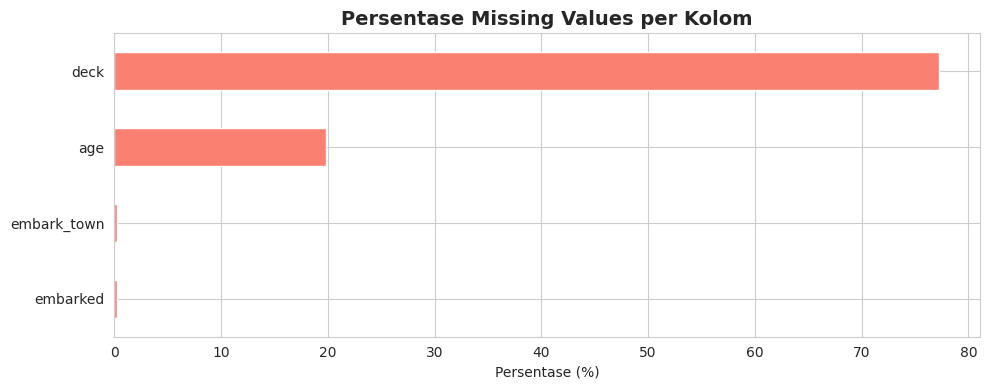

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].sort_values(ascending=True).plot(
    kind='barh', ax=ax, color='salmon'
)
ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Persentase (%)')
plt.tight_layout()
plt.show()

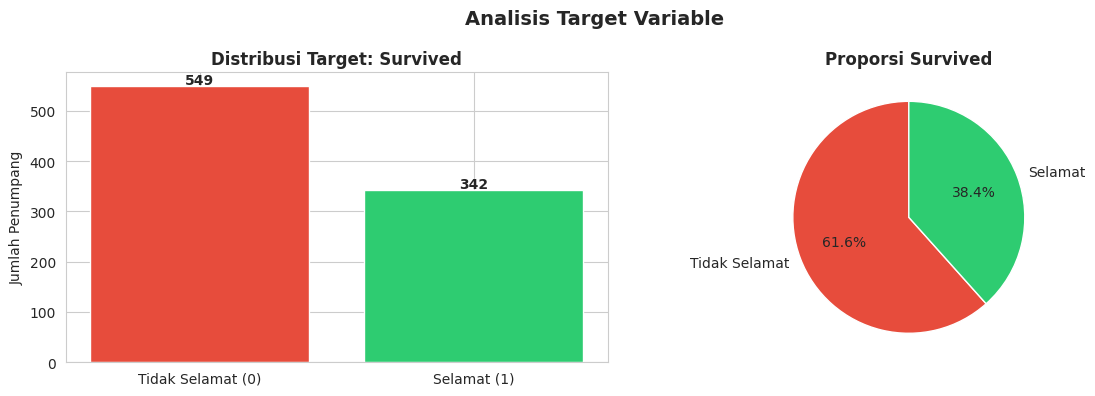


 Distribusi Target:
   Tidak Selamat (0): 549 (61.6%)
   Selamat (1)      : 342 (38.4%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['survived'].value_counts()
axes[0].bar(['Tidak Selamat (0)', 'Selamat (1)'],
            counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribusi Target: Survived', fontweight='bold')
axes[0].set_ylabel('Jumlah Penumpang')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Tidak Selamat', 'Selamat'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Proporsi Survived', fontweight='bold')

plt.suptitle('Analisis Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n Distribusi Target:')
print(f'   Tidak Selamat (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'   Selamat (1)      : {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

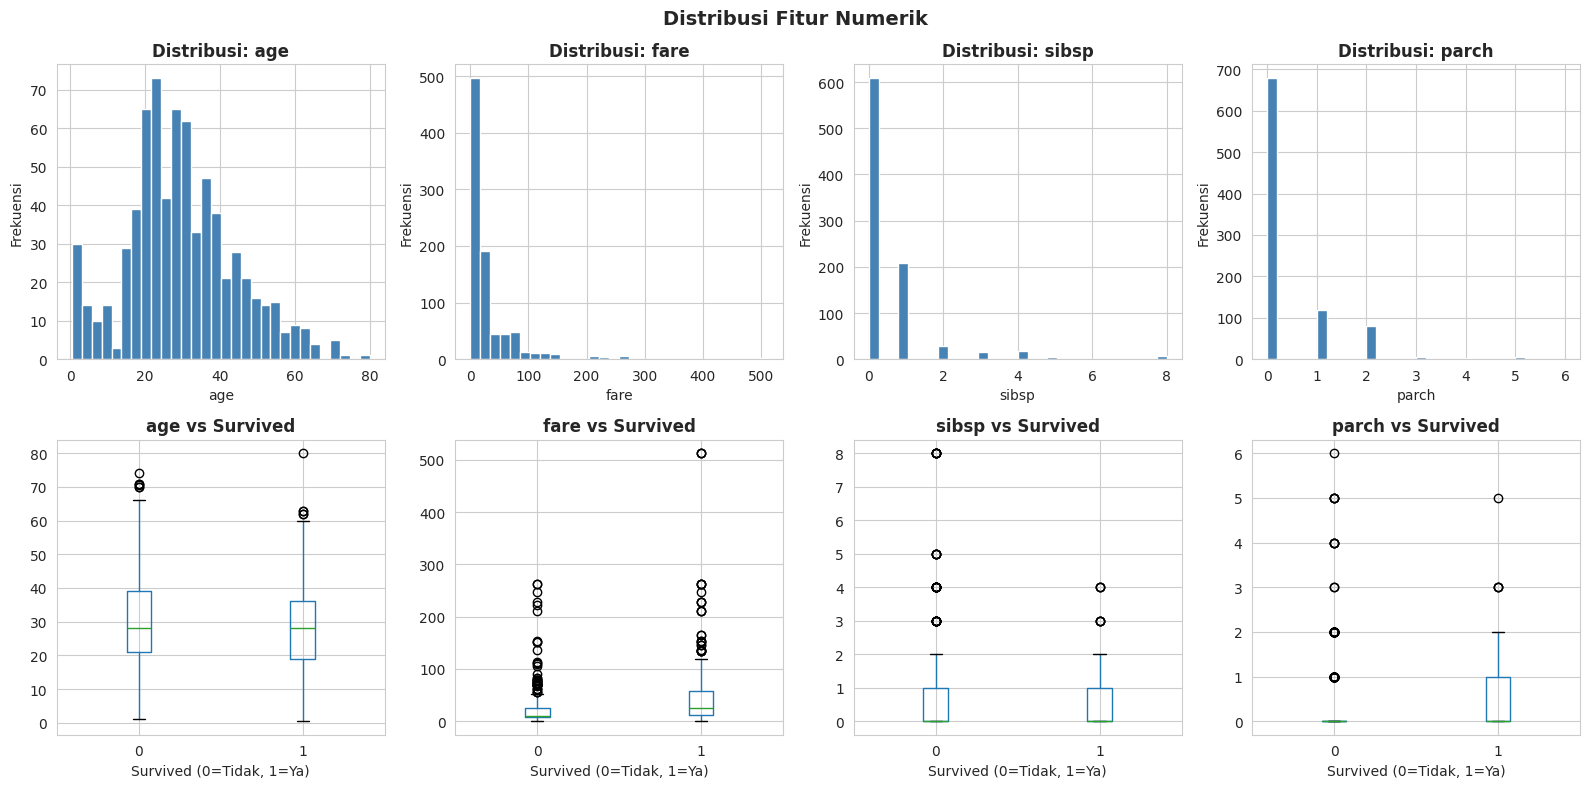

In [ ]:
numeric_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(numeric_cols):

    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot per survived
    df.boxplot(column=col, by='survived', ax=axes[1, i])
    axes[1, i].set_title(f'{col} vs Survived', fontweight='bold')
    axes[1, i].set_xlabel('Survived (0=Tidak, 1=Ya)')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

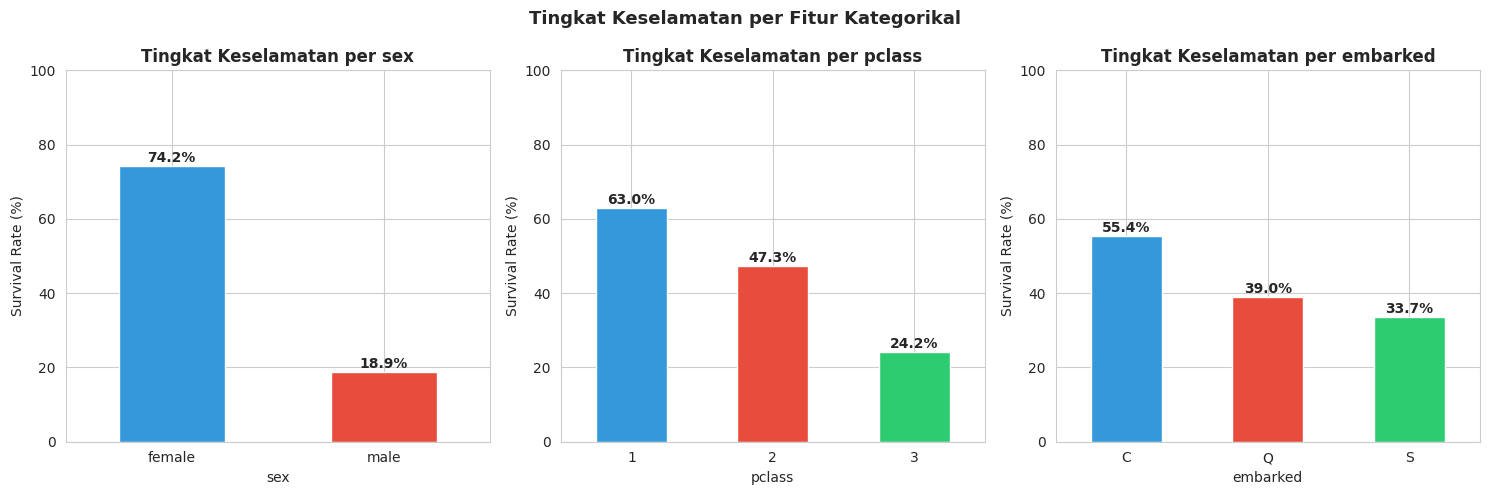

In [ ]:
cat_cols = ['sex', 'pclass', 'embarked']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    survival_rate = df.groupby(col)['survived'].mean() * 100
    survival_rate.plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c', '#2ecc71'],
                       edgecolor='white', rot=0)
    axes[i].set_title(f'Tingkat Keselamatan per {col}', fontweight='bold')
    axes[i].set_ylabel('Survival Rate (%)')
    axes[i].set_ylim(0, 100)
    for j, v in enumerate(survival_rate.values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Tingkat Keselamatan per Fitur Kategorikal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

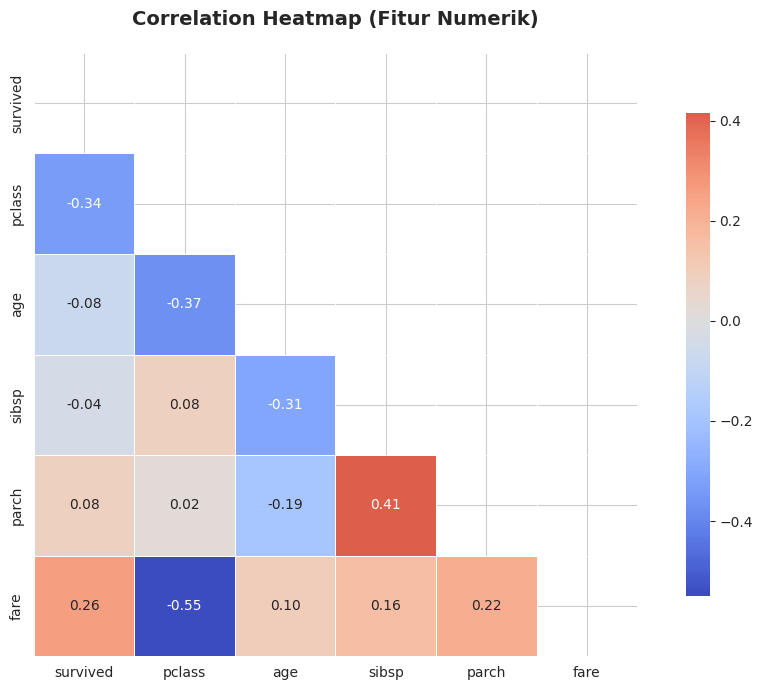


 Korelasi tertinggi dengan target (survived):
fare      0.26
parch     0.08
sibsp    -0.04
age      -0.08
pclass   -0.34
Name: survived, dtype: float64


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap (Fitur Numerik)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n Korelasi tertinggi dengan target (survived):')
print(corr_matrix['survived'].sort_values(ascending=False).drop('survived'))

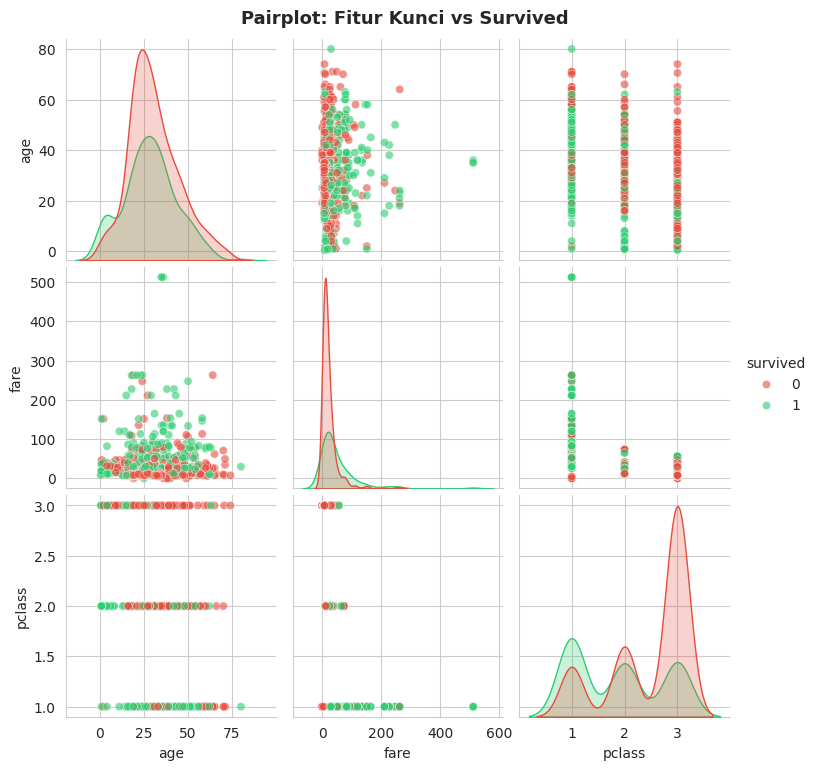

In [ ]:
key_features = ['survived', 'age', 'fare', 'pclass']

sns.pairplot(
    df[key_features].dropna(),
    hue='survived',
    palette={0: '#e74c3c', 1: '#2ecc71'},
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pairplot: Fitur Kunci vs Survived', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [ ]:
print('Deteksi Outlier menggunakan IQR:')
print('='*45)

for col in ['age', 'fare', 'sibsp', 'parch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f'   {col:10s}: {outliers:4d} outlier | rentang [{lower:.2f}, {upper:.2f}]')

print()
print('   Insight EDA:')
print('   1. Kolom age (19.9%) dan deck (77.2%) memiliki banyak missing value')
print('   2. Wanita memiliki tingkat keselamatan jauh lebih tinggi (74%) vs pria (19%)')
print('   3. Penumpang kelas 1 memiliki survival rate tertinggi (63%)')
print('   4. Fare memiliki distribusi sangat skewed ke kanan — perlu transformasi')
print('   5. Korelasi negatif antara pclass dan survived (-0.34)')

Deteksi Outlier menggunakan IQR:
   age       :   11 outlier | rentang [-6.69, 64.81]
   fare      :  116 outlier | rentang [-26.72, 65.63]
   sibsp     :   46 outlier | rentang [-1.50, 2.50]
   parch     :  213 outlier | rentang [0.00, 0.00]

   Insight EDA:
   1. Kolom age (19.9%) dan deck (77.2%) memiliki banyak missing value
   2. Wanita memiliki tingkat keselamatan jauh lebih tinggi (74%) vs pria (19%)
   3. Penumpang kelas 1 memiliki survival rate tertinggi (63%)
   4. Fare memiliki distribusi sangat skewed ke kanan — perlu transformasi
   5. Korelasi negatif antara pclass dan survived (-0.34)


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Mempersiapkan data yang siap digunakan.

Tahapan yang dilakukan:
1. Menghapus kolom tidak relevan
2. Menangani Missing Values
3. Encoding fitur kategorikal
4. Deteksi & penanganan outlier
5. Normalisasi fitur numerik
6. Pembagian data Train/Test

In [ ]:
df_processed = df.copy()

# Kolom yang akan dibuang:
# - 'deck'      : 77% missing, tidak praktis
# - 'embark_town': duplikasi info dari 'embarked'
# - 'alive'     : bocorkan target (survived)
# - 'class'     : duplikasi dari 'pclass'
# - 'who'       : derivasi dari 'sex' & 'age'
# - 'adult_male': derivasi dari 'sex'

cols_to_drop = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
df_processed.drop(columns=cols_to_drop, inplace=True)

print(f'   Kolom setelah seleksi: {list(df_processed.columns)}')
print(f'   Ukuran: {df_processed.shape}')

   Kolom setelah seleksi: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
   Ukuran: (891, 9)


In [ ]:
# age     : isi dengan median (robust terhadap outlier)
age_median = df_processed['age'].median()
df_processed['age'].fillna(age_median, inplace=True)

# embarked: isi dengan modus (Southampton adalah pelabuhan terbanyak)
embarked_mode = df_processed['embarked'].mode()[0]
df_processed['embarked'].fillna(embarked_mode, inplace=True)

# fare    : isi dengan median
fare_median = df_processed['fare'].median()
df_processed['fare'].fillna(fare_median, inplace=True)

# Verifikasi
remaining_missing = df_processed.isnull().sum().sum()
print(f'   Missing values setelah imputasi: {remaining_missing}')
print(f'   age    (diisi dengan median) : {age_median:.1f} tahun')
print(f'   embarked (diisi dengan modus): {embarked_mode}')
print(f'   fare   (diisi dengan median : {fare_median:.2f}')

   Missing values setelah imputasi: 0
   age    (diisi dengan median) : 28.0 tahun
   embarked (diisi dengan modus): S
   fare   (diisi dengan median : 14.45


In [ ]:
# sex: Binary encoding (male=1, female=0)
df_processed['sex'] = df_processed['sex'].map({'male': 1, 'female': 0})

# embarked: One-Hot Encoding (C, Q, S)
embarked_dummies = pd.get_dummies(df_processed['embarked'], prefix='embarked', drop_first=True)
df_processed = pd.concat([df_processed.drop('embarked', axis=1), embarked_dummies], axis=1)

# alone: boolean (int)
df_processed['alone'] = df_processed['alone'].astype(int)

print('    Encoding selesai!')
print(f'   Kolom setelah encoding: {list(df_processed.columns)}')
print(f'   Ukuran: {df_processed.shape}')
df_processed.head(3)

In [ ]:
Q1_fare = df_processed['fare'].quantile(0.25)
Q3_fare = df_processed['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

before_count = (df_processed['fare'] > upper_fare).sum()
df_processed['fare'] = df_processed['fare'].clip(upper=upper_fare)

print(f'Outlier fare: {before_count} nilai di-cap ke {upper_fare:.2f}')

# Log-transformasi fare untuk distribusi lebih normal
df_processed['fare'] = np.log1p(df_processed['fare'])
print(f'fare ditransformasi dengan log1p untuk mengurangi skewness')

Outlier fare: 116 nilai di-cap ke 65.63
fare ditransformasi dengan log1p untuk mengurangi skewness


In [ ]:
# Membuat fitur baru 'family_size' dari sibsp + parch
df_processed['family_size'] = df_processed['sibsp'] + df_processed['parch']

# Membuat fitur 'is_child' (usia < 16 tahun)
df_processed['is_child'] = (df_processed['age'] < 16).astype(int)

print('   Feature Engineering selesai!')
print('   Fitur baru: family_size, is_child')

   Feature Engineering selesai!
   Fitur baru: family_size, is_child


In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df_processed.drop('survived', axis=1)
y = df_processed['survived']

print(f'   Fitur (X): {X.shape}  |  Target (y): {y.shape}')
print(f'   Kolom fitur: {list(X.columns)}')

   Fitur (X): (891, 10)  |  Target (y): (891,)
   Kolom fitur: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone', 'family_size', 'is_child']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'   Dataset dibagi menjadi:')
print(f'   Training set : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Testing set  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.0f}%)')

   Dataset dibagi menjadi:
   Training set : 712 baris (80%)
   Testing set  : 179 baris (20%)


In [ ]:
# Fit hanya pada training data, transform keduanya
scaler = StandardScaler()

cols_to_scale = ['age', 'fare', 'sibsp', 'parch', 'family_size']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print('    Normalisasi StandardScaler selesai!')
print(f'   Kolom yang dinormalisasi: {cols_to_scale}')
print()
print('    Statistik X_train setelah scaling:')
X_train[cols_to_scale].describe().round(2)

    Normalisasi StandardScaler selesai!
   Kolom yang dinormalisasi: ['age', 'fare', 'sibsp', 'parch', 'family_size']

    Statistik X_train setelah scaling:


,age,fare,sibsp,parch,family_size
count,712.00,712.00,712.00,712.00,712.00
mean,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.23,-3.39,-0.47,-0.47,-0.56
25%,-0.57,-0.82,-0.47,-0.47,-0.56
50%,-0.11,-0.17,-0.47,-0.47,-0.56
75%,0.50,0.69,0.48,-0.47,0.07
max,3.88,1.55,7.08,6.70,5.74


In [ ]:
# Gabungkan kembali untuk disimpan
train_final = X_train.copy()
train_final['survived'] = y_train.values

test_final = X_test.copy()
test_final['survived'] = y_test.values

# Simpan ke CSV
train_final.to_csv('titanic_train_preprocessed.csv', index=False)
test_final.to_csv('titanic_test_preprocessed.csv', index=False)

print('   Dataset preprocessed berhasil disimpan!')
print('   titanic_train_preprocessed.csv')
print('   titanic_test_preprocessed.csv')
print()
print('   Sample data siap latih (X_train):')
X_train.head()

   Dataset preprocessed berhasil disimpan!
   titanic_train_preprocessed.csv
   titanic_test_preprocessed.csv

   Sample data siap latih (X_train):


,pclass,sex,age,sibsp,parch,fare,embarked,alone,family_size,is_child
692,3,male,-0.11,-0.47,-0.47,1.38,S,True,-0.56,0
481,2,male,-0.11,-0.47,-0.47,-3.39,S,True,-0.56,0
527,1,male,-0.11,-0.47,-0.47,1.55,S,True,-0.56,0
855,3,female,-0.88,-0.47,0.73,-0.64,S,False,0.07,0
801,2,female,0.12,0.48,0.73,0.50,S,False,0.70,0


In [ ]:
print('='*55)
print('        Ringkasan Pre-Processing Selesai')
print('='*55)
print(f'  Dataset awal       : {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')
print(f'  Dataset akhir      : {df_processed.shape[0]} baris, {df_processed.shape[1]} kolom')
print(f'  Missing values     : {df_processed.isnull().sum().sum()} (bersih)')
print(f'  Fitur training     : {X_train.shape[1]} kolom')
print(f'  Ukuran training set: {X_train.shape[0]} baris')
print(f'  Ukuran testing set : {X_test.shape[0]} baris')
print('='*55)
print('  Tahapan yang dilakukan:')
print('  [y] Seleksi & drop kolom tidak relevan')
print('  [y] Imputasi missing values (median/modus)')
print('  [y] Binary encoding (sex)')
print('  [y] One-Hot Encoding (embarked)')
print('  [y] Capping & log-transform outlier (fare)')
print('  [y] Feature engineering (family_size, is_child)')
print('  [y] Stratified train-test split (80:20)')
print('  [y] StandardScaler normalisasi')
print('  [y] Simpan CSV preprocessed')
print('='*55)

        Ringkasan Pre-Processing Selesai
  Dataset awal       : 891 baris, 15 kolom
  Dataset akhir      : 891 baris, 11 kolom
  Missing values     : 0 (bersih)
  Fitur training     : 10 kolom
  Ukuran training set: 712 baris
  Ukuran testing set : 179 baris
  Tahapan yang dilakukan:
  [y] Seleksi & drop kolom tidak relevan
  [y] Imputasi missing values (median/modus)
  [y] Binary encoding (sex)
  [y] One-Hot Encoding (embarked)
  [y] Capping & log-transform outlier (fare)
  [y] Feature engineering (family_size, is_child)
  [y] Stratified train-test split (80:20)
  [y] StandardScaler normalisasi
  [y] Simpan CSV preprocessed
